# PCA aplicado a imágenes satelitales

<div style="border-left: 4px solid #f0ad4e; padding: 0.5em 1em; background: #f5f5f5; color: black;">
<b>Atención! (Solo para quienes usen Conda): esta notebook requiere utilizar el env add-aml</b>

```bash
(conda env create -f environment_bonus.yml)
```

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import rasterio

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

## Exploramos la imagen

In [2]:
def normalize_percentile(band, pmin=2, pmax=98):
    # Normaliza una banda usando percentiles para mejorar el contraste

    lower = np.percentile(band, pmin)
    upper = np.percentile(band, pmax)
    denom = upper - lower

    if np.isclose(denom, 0):
        return np.zeros_like(band, dtype=float)

    return np.clip((band - lower) / denom, 0, 1)

In [3]:
with rasterio.open('../datasets/landsat_sample.tif') as src:
    img = src.read()                 # imagen
    profile = src.profile            # metadata
    nombres = list(src.descriptions) # bandas

bands, height, width = img.shape     # dimensiones

In [4]:
print(f'Dimensiones: {height} x {width}')

Dimensiones: 347 x 347


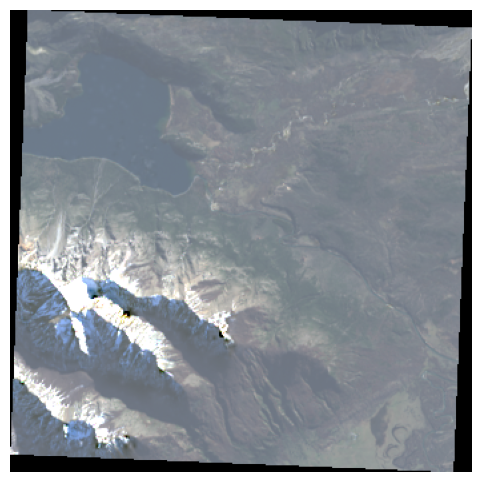

In [5]:
# Landsat 8: [4, 3, 2] → rojo, verde, azul

r = normalize_percentile(img[3])
g = normalize_percentile(img[2])
b = normalize_percentile(img[1])

# Composición de la imagen RGB normalizada
rgb_stretched = np.stack([r, g, b], axis=-1)

plt.figure(figsize=(6, 6))
plt.imshow(rgb_stretched)
plt.axis('off')
plt.show()


In [6]:
print(f'Bandas: {bands}')

Bandas: 19


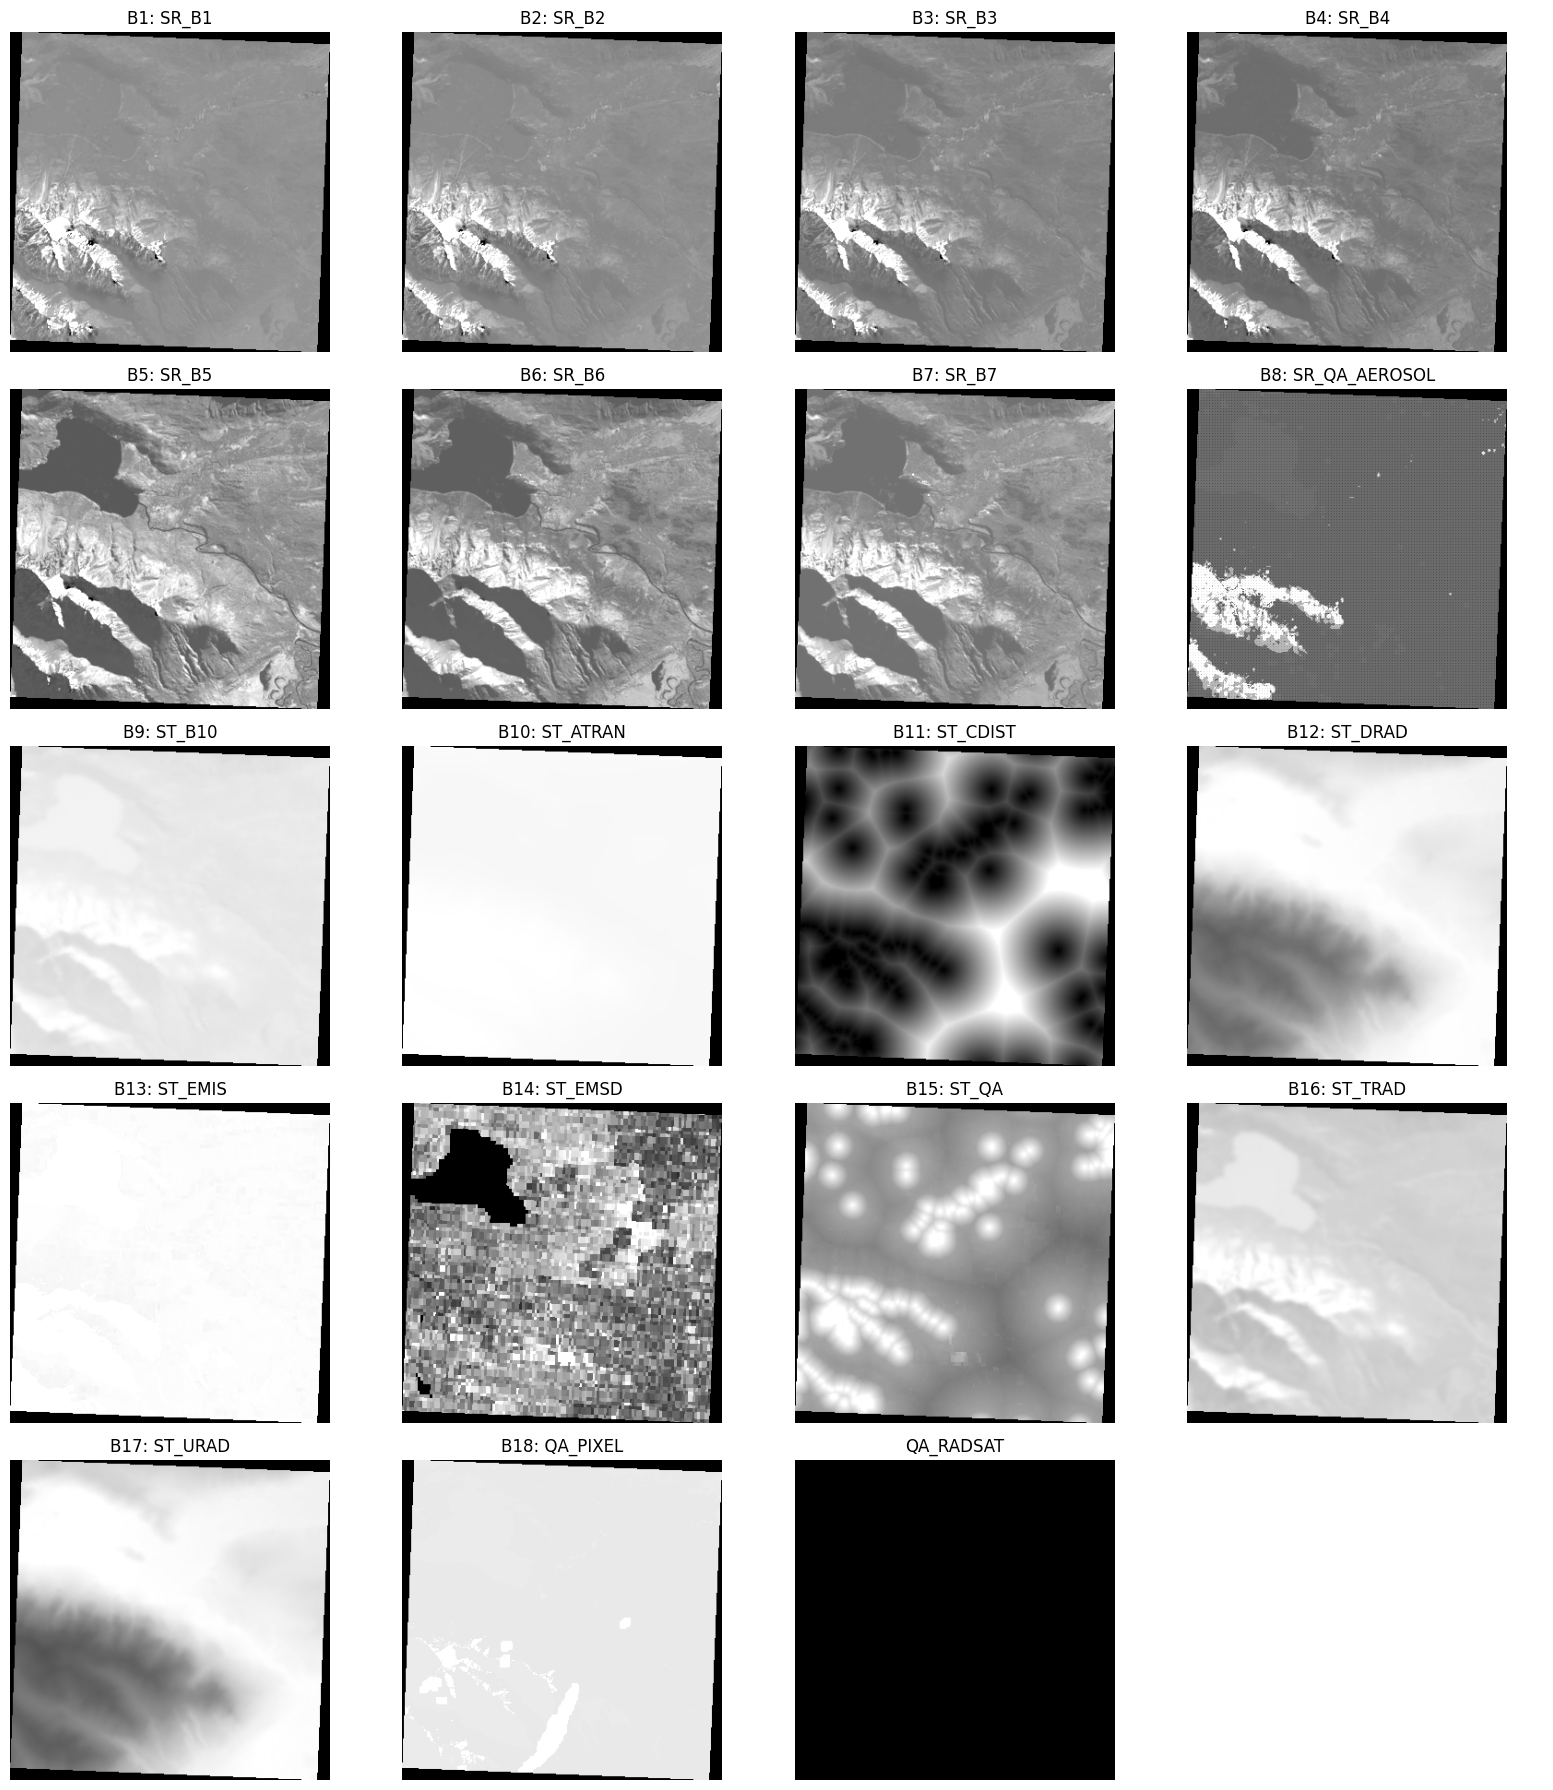

In [7]:
fig, axes = plt.subplots(5, 4, figsize=(16, 18))
axes = axes.ravel()

for i in range(bands):
    ax = axes[i]

    img_n = normalize_percentile(img[i])
    ax.imshow(img_n, cmap='gray')
    ax.set_title(f'B{i+1}: {nombres[i]}')
    ax.axis('off')

# Oculta el subplot sobrante
for j in range(bands, len(axes)):
    axes[j].axis('off')

ax.set_title(nombres[i])
plt.tight_layout()
plt.show()

## Aplicamos PCA

#### Preparamos los datos

In [8]:
img_2d = img.reshape(bands, -1).T  # shape: (pixels, bands)
X_scaled = StandardScaler().fit_transform(img_2d)
X_scaled.shape

(120409, 19)

### Paso 1) Calculamos los ejes principales PC1, PC2, etc.

In [9]:
pca = PCA(n_components=bands)
pca.fit(X_scaled)

PCA(n_components=19)

#### Loadings

Cuánto aporta cada variable a cada componente principal.

In [10]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index = nombres
)
loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19
SR_B1,0.247912,0.292561,-0.012222,0.165027,0.230462,0.122635,-0.073144,0.103669,-0.036899,-0.029696,-0.636208,0.160032,0.094931,-0.361155,0.411390,0.002337,-0.002751,0.001115,0.0
SR_B2,0.245166,0.311919,-0.044594,0.168383,0.201745,0.115926,-0.073908,0.130244,0.003646,-0.055603,-0.232467,0.104484,-0.092668,0.712469,-0.388876,-0.014385,-0.000388,-0.000698,0.0
SR_B3,0.244620,0.325978,-0.094396,0.142872,0.135791,0.094641,-0.020593,0.105353,0.022560,-0.084417,0.311958,-0.058797,0.184033,-0.532540,-0.582475,-0.022229,-0.002842,0.000058,0.0
SR_B4,0.240587,0.338660,-0.128048,0.122542,0.091685,0.090313,-0.020563,0.182180,0.008660,0.001953,0.512032,-0.298660,-0.348508,0.101364,0.511557,0.030973,0.001850,0.000075,0.0
SR_B5,0.244752,0.177332,-0.318577,-0.000071,-0.141472,0.042427,0.425350,-0.728602,0.011416,-0.147364,0.010073,0.001045,0.190136,0.091146,0.084512,0.000934,0.002827,-0.000760,0.0
SR_B6,0.238757,0.043546,-0.271100,-0.201085,-0.453386,-0.203894,0.172510,0.143118,-0.064456,0.197014,-0.262434,-0.013010,-0.590267,-0.171294,-0.199283,-0.017623,-0.001064,-0.001133,0.0
SR_B7,0.255336,0.060510,-0.190527,-0.184045,-0.380907,-0.217814,-0.002451,0.426630,-0.053553,0.114122,0.065829,0.020114,0.644599,0.171141,0.140330,0.035882,-0.000819,0.002929,0.0
SR_QA_AEROSOL,0.180781,0.054833,0.512316,-0.211810,0.287275,-0.308234,0.653280,0.164865,0.142510,-0.035237,0.033340,0.049261,-0.016898,0.005106,0.008814,-0.001409,-0.003052,-0.000110,0.0
ST_B10,0.280716,-0.158171,0.069113,-0.039822,-0.021932,-0.141849,-0.224657,-0.068757,0.158300,-0.218797,0.034235,0.038661,-0.036752,-0.001586,0.038473,-0.546956,0.067143,0.657204,0.0
ST_ATRAN,0.278051,-0.165179,0.125417,-0.063076,0.038500,-0.108322,-0.195286,-0.108759,0.060053,-0.048591,-0.128112,-0.475986,0.051281,0.013852,-0.024409,-0.422339,-0.010714,-0.617794,0.0


#### Contribuciones porcentuales por componente

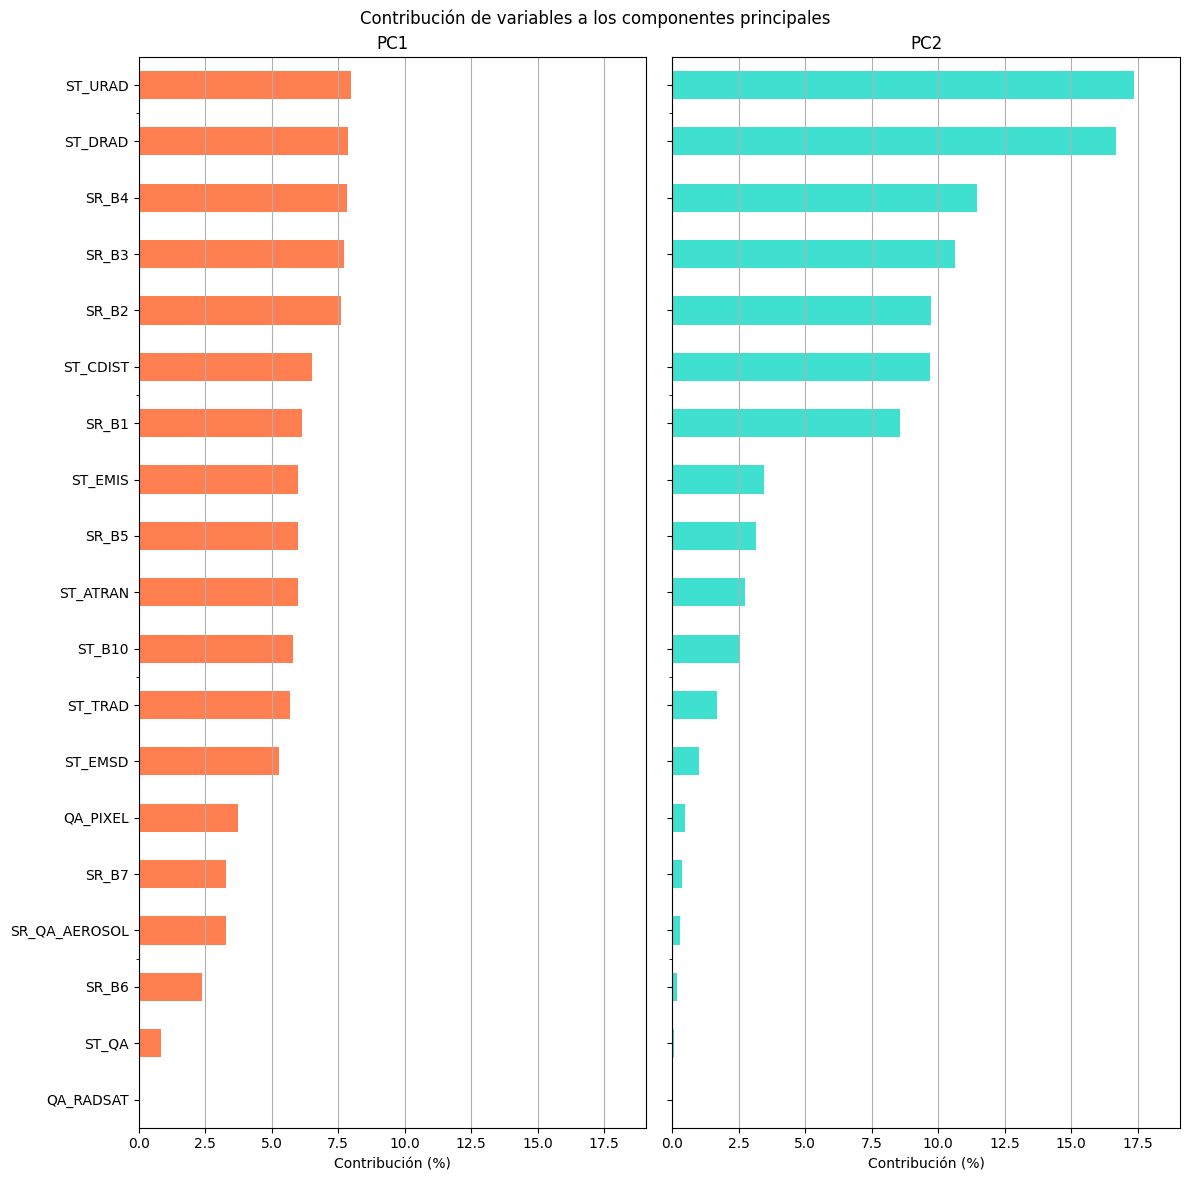

In [11]:
# Contribuciones porcentuales
contrib = (loadings**2)
contrib = contrib.div(contrib.sum(axis=0), axis=1) * 100

fig, ax = plt.subplots(1, 2, figsize=(12, 12), sharey=True)

# PC1
contrib["PC1"].sort_values().plot.barh(ax=ax[0], color='coral')
ax[0].set_title("PC1")
ax[0].set_xlabel("Contribución (%)")
ax[0].grid(axis='x')

# PC2
contrib["PC2"].sort_values().plot.barh(ax=ax[1], color='turquoise')
ax[1].set_title("PC2")
ax[1].set_xlabel("Contribución (%)")
ax[1].grid(axis='x')

# escala
max_val = contrib[["PC1", "PC2"]].max().max()
ax[0].set_xlim(0, max_val * 1.1)
ax[1].set_xlim(0, max_val * 1.1)

plt.suptitle("Contribución de variables a los componentes principales")
plt.tight_layout()
plt.show()

### Paso 2) Calculamos los datos proyectados sobre los ejes principales.

#### Scores
Datos proyectados sobre los componentes principales.

In [12]:
X_pca = pca.transform(X_scaled)
X_pca.shape

(120409, 19)

#### Graficamos los dos primeros componentes

#### IMPORTANTE!
PCA no conserva las bandas individuales. Por lo tanto, se pierde interpretabilidad.

In [13]:
pca_image = X_pca[:, :2].T.reshape(2, height, width)
pca_image.shape

(2, 347, 347)

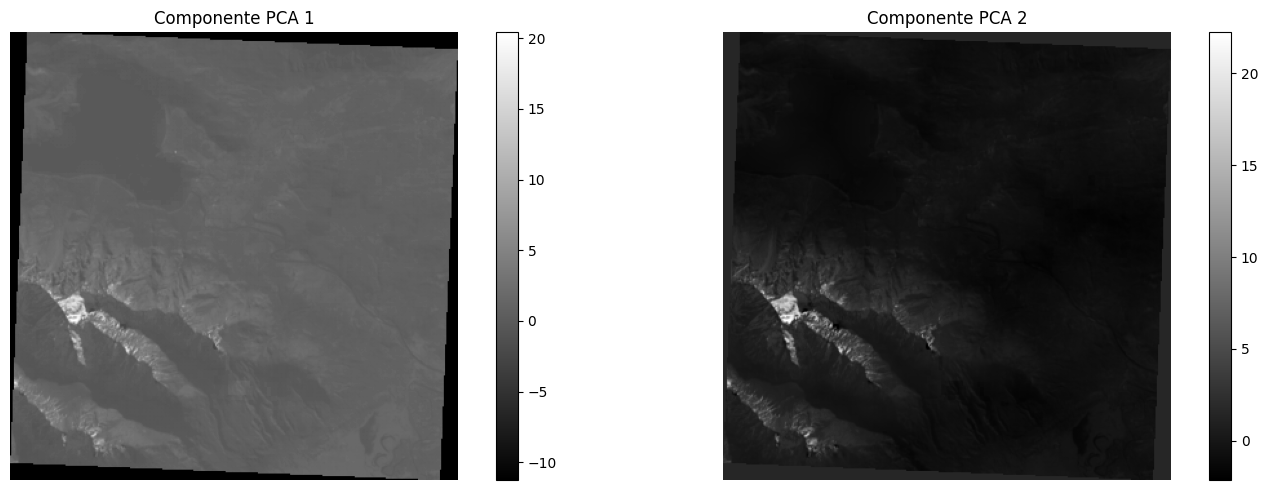

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for i in range(2):
    img = axes[i].imshow(pca_image[i], cmap='gray')
    axes[i].set_title(f'Componente PCA {i+1}')
    axes[i].axis('off')
    fig.colorbar(img, ax=axes[i])
    
plt.tight_layout()
plt.show()

### Explicamos la varianza

In [15]:
# varianza explicada por cada componente
explained_var = pca.explained_variance_ratio_

# varianza acumulada
cumulative_var = np.cumsum(explained_var)

n_components = len(explained_var)
componentes = np.arange(1, n_components + 1)

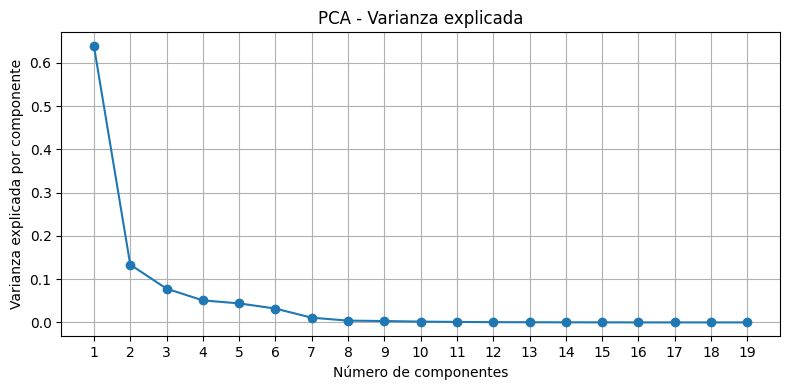

Varianza explicada por cada componente:
[6.38902148e-01 1.33619827e-01 7.80570741e-02 5.09262287e-02
 4.39929997e-02 3.19528818e-02 1.09018950e-02 4.12889631e-03
 3.18531177e-03 1.84146581e-03 1.13397548e-03 6.15047916e-04
 3.75816157e-04 2.14208750e-04 1.24294598e-04 2.59122040e-05
 1.87835240e-06 1.38492808e-07 0.00000000e+00]


In [16]:
# varianza explicada por cada componente
plt.figure(figsize=(8, 4))
plt.plot(componentes, explained_var, marker='o')
plt.xticks(componentes)
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada por componente')
plt.title('PCA - Varianza explicada')
plt.grid(True)
plt.tight_layout()
plt.show()

print(f'Varianza explicada por cada componente:\n{explained_var}')

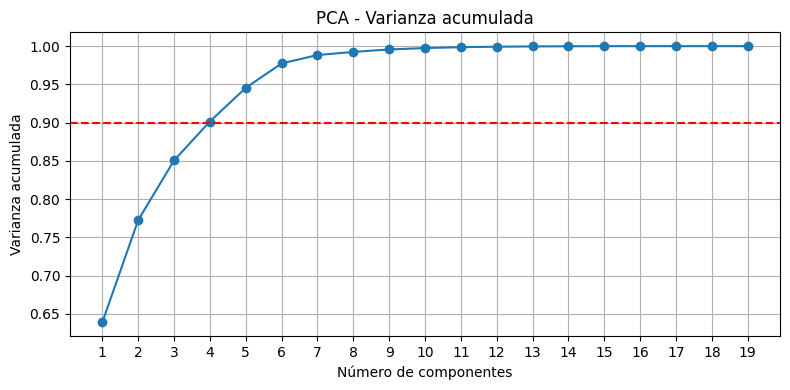

Varianza explicada acumulada:
[0.63890215 0.77252197 0.85057905 0.90150528 0.94549828 0.97745116
 0.98835305 0.99248195 0.99566726 0.99750873 0.9986427  0.99925775
 0.99963357 0.99984778 0.99997207 0.99999798 0.99999986 1.
 1.        ]


In [17]:
plt.figure(figsize=(8, 4))
plt.plot(componentes, cumulative_var, marker='o')
plt.xticks(componentes)
plt.xlabel('Número de componentes')
plt.ylabel('Varianza acumulada')
plt.title('PCA - Varianza acumulada')
plt.grid(True)
plt.axhline(y=0.9, color='red', linestyle='--', label='90% de varianza')
plt.tight_layout()
plt.show()

print(f'Varianza explicada acumulada:\n{cumulative_var}')